In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from get_model_probabilities import *
import scienceplots
plt.style.use(["science","grid"])
from sidm_inference_on_data_and_models import infer_sidm
from scipy.stats import binned_statistic
from matplotlib import gridspec

DEFAULT ZS 2.28808070104492
Source redshift:2.2884950162268827


In [541]:
systematics = {
            'cluster_member_contamination': f"pickles/cluster_contamination_concat.pkl",
        'projection_integration':"pickles/flamingo_dz_results.pkl",
    'shape_measurement_bias':"pickles/shape_measurement_concat_test.pkl",
     'source_redshift_bias':"pickles/all_models_concat_nzbias_results.pkl",

}   
systematics_thresh= {
        'mass_dependency': "pickles/mass_data_zs_dependence.pkl",
    'merging_scenario':"pickles/component_results.pkl"
}


cluster_member_contamination
shape_measurement_bias
source_redshift_bias
projection_depth


Text(0.5, 0, '$\\log_{10}\\!\\left[(\\sigma_{\\rm DM}/m)/(\\mathrm{cm}^2\\,\\mathrm{g}^{-1})\\right]$')

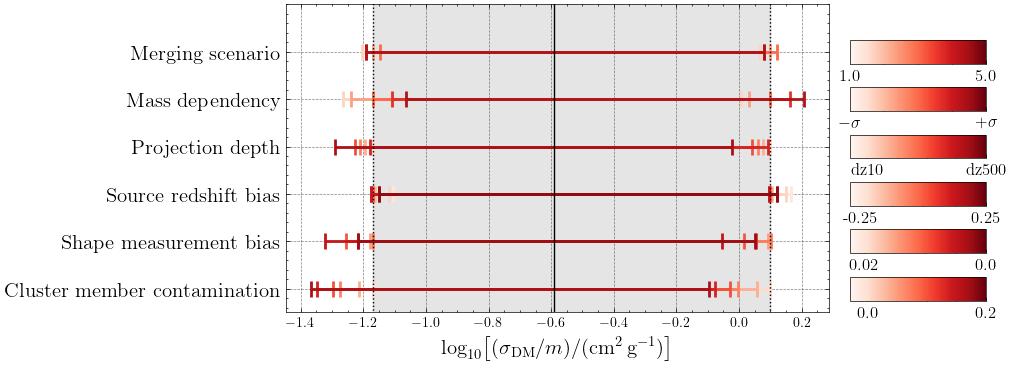

In [5]:
systematics = {
            'cluster_member_contamination': f"pickles/cluster_contamination_concat.pkl",
    'shape_measurement_bias':"pickles/shape_measurement_concat_test.pkl",
     'source_redshift_bias':"pickles/all_models_concat_nzbias_results.pkl",
        'projection_depth':"pickles/flamingo_dz_results.pkl"
}   
systematics_thresh= {
        'mass_dependency': "pickles/mass_data_zs_dependence.pkl",
    'merging_scenario':"pickles/component_results.pkl"
}


fig = plt.figure(figsize=(7,4))
ax = plt.gca()
corr = 2.8
systematic_names = []

capsize = 6

models, probabilities, probabilities_noise = pkl.load(open("pickles/model_on_data.pkl","rb"))

bahamas_fid = None
central_value = 0.52
central_error = 0.0083

central_cross_value = -0.59
central_cross_error = np.array([0.58,0.69])[:,None]


for isx, isystematic in enumerate(systematics.keys()):
    
    fiducial, all_results = pkl.load(open(systematics[isystematic],"rb"))
    

    print(isystematic)
    ibias_keys = np.sort(list(all_results.keys()))


        
    colors = colourFromRange([-1,len(ibias_keys)], cmap='Reds')

    norm = mpl.colors.Normalize(vmin=-2, vmax=len(all_results.keys()))
    cmap = plt.cm.Reds

    
    for ibx, ibias in enumerate(ibias_keys):
        bias_thresholds = []
        fid_thresholds = []
        color = cmap(norm(ibx))
        for imodel in all_results[ibias].keys():
            if 'seed' not in imodel:
                continue
                
            if isinstance(all_results[ibias][imodel],dict):

                    
                tgt = get_threshold_for_cross( 
                    all_results[ibias][imodel]['src'], 
                    quiet=False)
                
                fid = get_threshold_for_cross( 
                    fiducial[imodel]['src'], 
                    quiet=False)
            elif isinstance(all_results[ibias][imodel],list):
                
                tgt = get_threshold_for_cross( 
                    all_results[ibias][imodel], 
                    quiet=False)
                fid = get_threshold_for_cross( 
                    fiducial[imodel], 
                    quiet=False)
                
            bias_thresholds.append(1-tgt['thresholds'])
            fid_thresholds.append(1-fid['thresholds'])
 
        bias_means = np.mean(np.array(bias_thresholds), axis=0)
        fid_means = np.mean(np.array(fid_thresholds), axis=0)
   
        #means = np.nanmean(all_thresholds,axis=0) * central_value
        #errors = np.std(all_thresholds,axis=0) / np.sqrt(all_thresholds.shape[0]) 
        
        if bahamas_fid is None:
            bahamas_fid = fid_means.copy()
            cross_sections = tgt['cross_sections'].copy()
            
        if isystematic == 'projection_depth':
            
            bias_impact = bias_means / fid_means
            
            
            bias_means = bias_impact*bahamas_fid
            
            fid_means = bahamas_fid.copy()
            
            
        sidm, sidm_error = infer_sidm(
            probabilities['concat'],
            { icross:bias_means[icx] for icx, icross in enumerate(cross_sections)})
    
        sidm_fid, sidm_error_fid = infer_sidm(
            probabilities['concat'],
            { icross:fid_means[icx] for icx, icross in enumerate(cross_sections)})
        
        biased_value = sidm-sidm_fid+central_cross_value
        
        ax.errorbar( biased_value, isx, xerr=central_cross_error, 
                    capsize=capsize, color=colors[ibx], lw=2, capthick=2)
    
    cax = inset_axes(
        ax,
        width="25%",      # width of colorbar
        height="50%",      # thickness
        loc="center right",
        bbox_to_anchor=(0.29, isx-0.5, 1, 1),
        bbox_transform=ax.get_yaxis_transform(),
        borderpad=0,
    )

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = plt.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_ticks([-1,len(ibias_keys)])
    if isystematic =='shape_measurement_bias':
        ibias_keys = ibias_keys.astype(float)
        ibias_keys[0] = 0.02
        ibias_keys[-1] = 0.00
    if isystematic == 'source_redshift_bias':
        ibias_keys = ibias_keys.astype(float)
        ibias_keys -= 1
    cbar.set_ticklabels([ibias_keys[0], ibias_keys[-1]])
    cbar.ax.tick_params(labelsize=12)
    
    
    systematic_names.append(isystematic.replace('_',' ').capitalize())

for isy, isystematic in enumerate(systematics_thresh.keys()):
    
    fiducial, results = pkl.load(open(systematics_thresh[isystematic],"rb"))
    
    colors = colourFromRange([-1,len(results.keys())], cmap='Reds')
  
    ibias_keys = np.sort(list(results.keys()))
    colors = colourFromRange([-1,len(ibias_keys)], cmap='Reds')
    

    norm = mpl.colors.Normalize(vmin=-1, vmax=len(ibias_keys))
    cmap = plt.cm.Reds  
    for ibx, ibias in enumerate(ibias_keys):
        
        if 'thresholds' in list(results[ibias]['bahamas'].keys()):
            means = 1-np.mean(results[ibias]['bahamas']['thresholds'],axis=0)
            fid_means = 1-np.mean(fiducial['bahamas']['thresholds'],axis=0)
            cross_sections =  results[ibias]['bahamas']['cross_section']

        else:
            means = 1-results[ibias]['bahamas']['mean']
            fid_means = 1-fiducial['bahamas']['mean']
    
           
        sidm, sidm_error = infer_sidm(
            probabilities['concat'],
            { icross:means[icx] for icx, icross in enumerate(cross_sections)})


        sidm_fid, sidm_error_fid = infer_sidm(
            probabilities['concat'],
            { icross:fid_means[icx] for icx, icross in enumerate(cross_sections)})
        
        biased_value = sidm-sidm_fid+central_cross_value
        ax.errorbar(biased_value, isy+isx+1, 
                    xerr = central_cross_error, 
                    capsize=capsize, color=colors[ibx], lw=2, capthick=2)
    
    cax = inset_axes(
        ax,
        width="25%",      # width of colorbar
        height="50%",      # thickness
        loc="center right",
        bbox_to_anchor=(0.29, isy+isx-0.5+1, 1, 1),
        bbox_transform=ax.get_yaxis_transform(),
        borderpad=0,
    ) 
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = plt.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_ticks([-1,len(ibias_keys)])
    if isystematic =='merging_scenario':
        ibias_keys = ibias_keys.astype(float)
        ibias_keys += 1

    if isystematic == 'mass_dependency':
        ibias_keys = ibias_keys.astype(str)
        ibias_keys[0] = r"$-\sigma$"
        ibias_keys[-1] = r"$+\sigma$"
    

    cbar.set_ticklabels([ibias_keys[0], ibias_keys[-1]])
    cbar.ax.tick_params(labelsize=12)
    
    
    systematic_names.append(isystematic.replace('_',' ').capitalize())
ax.set_yticks(np.arange(len(systematic_names)))
ax.set_yticklabels(systematic_names, fontsize=15)   



ax.plot( [central_cross_value, central_cross_value],  [-1,len(systematic_names)+1], color='k')
ax.plot( [central_cross_value-central_cross_error[0], central_cross_value-central_cross_error[0]],  [-1,len(systematic_names)+1], ':', color='k')
ax.plot( [central_cross_value+central_cross_error[1], central_cross_value+central_cross_error[1]],  [-1,len(systematic_names)+1],  ':',color='k')

ax.fill_between( 
    [central_cross_value-central_cross_error[0][0], central_cross_value+central_cross_error[1][0]],
    [-1,-1], [len(systematic_names)+1]*2, color='k', alpha=0.1
)





ax.set_ylim(-0.5,len(systematic_names))
ax.set_xlabel(
    r'$\log_{10}\!\left[(\sigma_{\rm DM}/m)/(\mathrm{cm}^2\,\mathrm{g}^{-1})\right]$', fontsize=15
)

## galaxy selection

PDFCROP 1.40, 2020/06/06 - Copyright (c) 2002-2020 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `plots/galaxy_selection.pdf'.


0

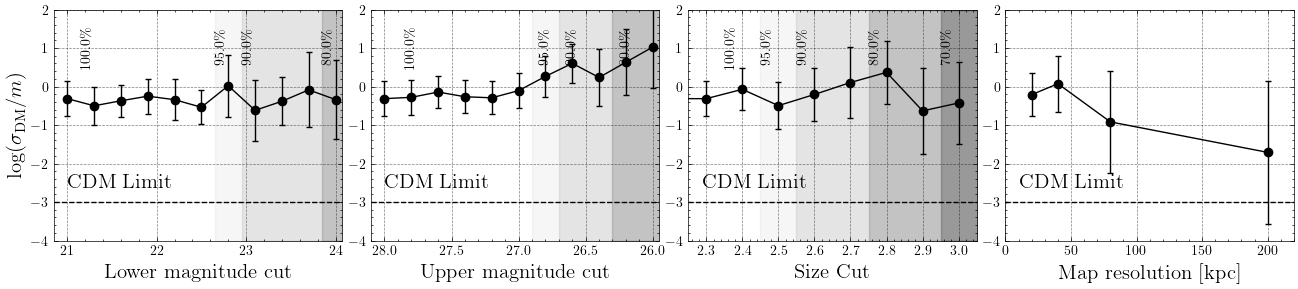

In [634]:
alpha =0.7
text_ypt=1
ylim=[-4,2]
limits = [1.0,0.95,0.9,0.8,0.7]
srcresults, tgtresults    = pkl.load(open("pickles/all_models_concat_ngal_dep_results.pkl", "rb"))

models, probabilities, probabilities_noise, ngalaxies = pkl.load( open("pickles/model_on_data_galaxy_selection.pkl","rb"))
ngalkeys = np.array(list(srcresults.keys())).astype(float)

all_mag_low_cuts = np.linspace(21,24,11)
all_mag_cuts = np.linspace(28,26,11)
all_siz_cuts = np.linspace(2,3,11)

fig, ax = plt.subplots(1,4,figsize=(16,3))
fig.subplots_adjust(wspace=0.1)
fmt = {'capsize':2,'color':'k','fmt':'o-'}

#### FIRST PLOT OF MAGNITUDE LIMISIT ####
cross = []
error = []
ngal = ngalaxies/ngalaxies[0]

    
for itest in range(11):
    probs = {}
    
    ngalkey= ngalkeys[ np.argmin(np.abs(ngalkeys-ngal[itest]))]
    
    for idx, i in enumerate(srcresults['1.00'][0]):
        #Since i use data from the findl results.
        #Rescale the probabilities to the correct full sample, mass matched and component match version.

        probs[i] = (srcresults[f"{ngalkey:0.2f}"][1][idx]-srcresults[f"{ngalkey:0.2f}"][1][0])*2.5+ 0.51
        
    data = probabilities_noise['concat'][:,itest]
    
    bias_sidm, bias_error = infer_sidm(
        data,
        probs,
    )
    
    cross.append(bias_sidm)
    error.append(bias_error)


    
ax[0].errorbar( all_mag_low_cuts, cross, np.array(error).T, **fmt)

for limit in limits:
    if np.sum( ngal[:11] < limit) == 0:
        continue
        
    dx = (all_mag_low_cuts[1] - all_mag_low_cuts[0])/2.
    x = np.linspace( 
        all_mag_low_cuts[ ngal[:11] <= limit][0]-dx,
        all_mag_low_cuts[ ngal[:11] <= limit][-1]+dx*3,
        100
    )
    y_low =np.full_like(x, ylim[0])
    y_hi = np.full_like(x, ylim[1])

    ax[0].fill_between( 
        x, y_low, y_hi, color='k', alpha=alpha*(1-limit)
    )
    ax[0].text(
        all_mag_low_cuts[ ngal[:11]  < limit][0]-dx, text_ypt, f"{limit*100}\%", va='center', ha='left', rotation=90)
    
    ax[0].set_xlim(
        all_mag_low_cuts[0]-dx,
        all_mag_low_cuts[-1] +dx/2.
    )
    


cross = []
error = []
for itest in range(11,22):
    probs = {}
    ngalkey= ngalkeys[ np.argmin(np.abs(ngalkeys-ngal[itest]))]

    for idx, i in enumerate(srcresults['1.00'][0]):
        #Since i use data from the findl results.
        #Rescale the probabilities to the correct full sample, mass matched and component match version.
        probs[i] = (srcresults[f"{ngalkey:0.2f}"][1][idx]-srcresults[f"{ngalkey:0.2f}"][1][0])*2.5+ 0.51
    data = probabilities_noise['concat'][:,itest]
   
    bias_sidm, bias_error = infer_sidm(
        data,
        probs,
    )
    
    cross.append(bias_sidm)
    error.append(bias_error)
    
ax[1].errorbar( all_mag_cuts, cross, np.array(error).T, **fmt)
x

for limit in limits:
    if np.sum( ngal[11:22] < limit) == 0:
        continue
        
    dx = (all_mag_cuts[1] - all_mag_cuts[0])/2.
    x = np.linspace( 
        all_mag_cuts[ ngal[11:22] <= limit][0]-dx,
        all_mag_cuts[ ngal[11:22] <= limit][-1]+dx*3,
        100
    )
    y_low =np.full_like(x, ylim[0])
    y_hi = np.full_like(x, ylim[1])

    
    ax[1].fill_between( 
        x, y_low, y_hi, color='k', alpha=alpha*(1-limit)
    )
    ax[1].text(
        all_mag_cuts[ ngal[11:22] < limit][0]-dx/2., text_ypt, f"{limit*100}\%", va='center', ha='left', rotation=90)
    
    ax[1].set_xlim(
        all_mag_cuts[0]-dx,
        all_mag_cuts[-1] +dx/2.
    )
    

###### FINAL PLOT
cross = []
error = []

for itest in range(22,33):
    probs = {}
    ngalkey= ngalkeys[ np.argmin(np.abs(ngalkeys-ngal[itest]))]
    
    for idx, i in enumerate(srcresults['1.00'][0]):
        #Since i use data from the final results.
        #Rescale the probabilities to the correct full sample, mass matched and component match version.

        probs[i] = (srcresults[f"{ngalkey:0.2f}"][1][idx]-srcresults[f"{ngalkey:0.2f}"][1][0])*2.5+ 0.51
        
    data = probabilities_noise['concat'][:,itest]
 
    bias_sidm, bias_error = infer_sidm(
        data,
        probs,
    )
    
    cross.append(bias_sidm)
    error.append(bias_error)
    
ax[2].errorbar( all_siz_cuts, cross, np.array(error).T, **fmt)

for limit in limits:
    if np.sum( ngal[22:] < limit) == 0:
        continue
        
    dx = (all_siz_cuts[1] - all_siz_cuts[0])/2.
    x = np.linspace( 
        all_siz_cuts[ ngal[22:] <= limit][0]-dx,
        all_siz_cuts[ ngal[22:] <= limit][-1]+dx*3,
        100
    )
    y_low =np.full_like(x, ylim[0])
    y_hi = np.full_like(x, ylim[1])
    
    ax[2].fill_between( 
        x, y_low, y_hi, color='k', alpha=alpha*(1-limit)
    )
    ax[2].text(
        all_siz_cuts[ ngal[22:] < limit][0]-dx, text_ypt, f"{limit*100}\%", va='center', ha='left', rotation=90)
    
    ax[2].set_xlim(
        2.25,
        all_siz_cuts[-1] +dx
    )
    ax[2].set_xticks(np.linspace(2.3,3,8))
    
ax[0].set_xlabel("Lower magnitude cut", fontsize=15)

ax[1].set_xlabel("Upper magnitude cut", fontsize=15)
    
ax[2].set_xlabel("Size Cut", fontsize=15)


ax[0].set_ylabel(
    "$\log(\sigma_{\\rm DM}/m$)", fontsize=15
)
for iax in ax:
    iax.set_ylim(ylim[0],ylim[1])
    iax.plot( [iax.get_xlim()[0], iax.get_xlim()[1]], [-3,-3],'k--')
    iax.text( 0.05, 2/8, "CDM Limit", va="center", transform=iax.transAxes, fontsize=15)
##########################
#########################D
# DATA PIXELISATION
#########################
output_name = f"pickles/resolution_dep_results.pkl"

thresholds = pkl.load(open(output_name,'rb'))

#get the fiducial resolution results
fiducial_name = f"pickles/all_models_{ifilter}_nz_results.pkl"
fid_res_results = pkl.load(open(fiducial_name,'rb'))
thresholds[20] = {
        k: v['src']
        for k, v in fid_res_results.items()
    }

tgtresults = {}
srcresults = {}

correction = 2.
for ikx, ikey in enumerate(thresholds.keys()):
    
    all_results = thresholds[ikey]
    
    


    for itgt in range(2):
        all_thresholds = []
        for imodel in all_results.keys():

            seed = float(imodel.split('_')[1])                


            tgt = get_threshold_for_cross( 
                [ all_results[imodel][i*2+itgt] for i in range(len(all_results[imodel])//2) ], 
                quiet=False)

            all_thresholds.append(tgt['thresholds'])

        all_thresholds = np.array(all_thresholds)
        means = 1-np.nanmean(all_thresholds,axis=0)
        errors = np.std(all_thresholds,axis=0) / all_thresholds.shape[0]**0.38*correction
            
        if itgt == 0:
            tgtresults[ikey] = { k:means[ik] for ik, k in enumerate(tgt['cross_sections'])}
        else:
            srcresults[ikey] = { k:means[ik] for ik, k in enumerate(tgt['cross_sections'])}


models, probabilities, probabilities_noise = pkl.load( open("pickles/model_on_data_pixelisation.pkl","rb") )

cross = []
error = []
for ipx, ipixel in enumerate(srcresults.keys()):
    
    
    
    data = probabilities_noise['concat'][:,ipx]
    probs = {}
    for idx in srcresults[ipixel].keys():
        #probs[idx] = (srcresults[ipixel][idx]-srcresults[ipixel][0.0])*2+0.52
        #Recalibrate due to lack of no finetuning - we just want the change in threshold - the absolute 
        #amount just is shifted by the fine-tuning.
        probs[idx] = srcresults[ipixel][idx]-srcresults[ipixel][0.0] + srcresults[20][0.0],

    bias_sidm, bias_error = infer_sidm(
        data,
        probs,
    )
    
    cross.append(bias_sidm)
    error.append(bias_error)

ax[3] = plt.gca()
ax[3].errorbar(thresholds.keys(),cross, np.array(error).T, capsize=2, fmt='o-', color='k')
ax[3].set_xlabel('Map resolution [kpc]', fontsize=15)

ax[3].set_xlim(0,220)
ax[3].plot( [ax[3] .get_xlim()[0], ax[3] .get_xlim()[1]], [-3,-3],'k--')
fig.align_xlabels()

fname='plots/galaxy_selection.pdf'
plt.savefig(fname)
os.system(f"pdfcrop {fname} {fname}")